# Making models with Bagpipes

This example will show you how to make a model galaxy spectrum. The two main steps in this process are defining the physical parameters of the galaxy you would like to model, and defining the observables (spectroscopy and/or photometry) you would like to obtain predictions for.

You'll need to understand the syntax used here before moving on to fitting observational data. For further information see the [making model galaxies](http://bagpipes.readthedocs.io/en/latest/model_galaxies.html) page of the documentation.

## The model_components dictionary

Instructions about what kind of model to make are passed to the code via the [model components dictionary](https://bagpipes.readthedocs.io/en/latest/model_components.html). Each "component" is a sub-dictionary containing information about either the star-formation history, the dust model or the nebular emission model. A number of global properties can also be specified. The only required components are the observed redshift, and at least one star formation history component.

A simple tau model with Calzetti dust can be set up as follows.

## Defining filter curves

If you would like to obtain predictions for photometric fluxes which would be observed for an object with the parameters listed above, you'll first need to define a list of filter curves, or filt_list, for the code to calculate photometric fluxes through.

A filt_list simply contains paths from the current working directory (or absolute paths) to the locations the filter curve files are stored. Filter curve files should start with a column of wavelengths in Angstroms, followed by a column of relative transmission values.

Through these examples we'll stick with the [CANDELS GOODS South catalogue](https://archive.stsci.edu/prepds/candels/) of Guo et al. (2013). The filters are as follows.

In [11]:
import bagpipes as pipes
import numpy as np
import matplotlib as plt
import os

In [12]:
goodss_filt_list = ["filters/VIMOS_U",
                    "filters/f435w",
                    "filters/f606w",
                    "filters/f775w",
                    "filters/f850lp",
                    "filters/f098m",
                    "filters/f105w",
                    "filters/f125w",
                    "filters/f160w",
                    "filters/ISAAC_Ks",
                    "filters/HAWKI_K",
                    "filters/IRAC1",
                    "filters/IRAC2",
                    "filters/IRAC3",
                    "filters/IRAC4"]

I usually find it more convenient to store these in a text file and load them up as an array:

In [13]:
filter_folder = r"D:\Users\nina\Star_Formation_Histories\Filters"

filter_files = sorted([
    os.path.join(filter_folder, f)
    for f in os.listdir(filter_folder)
    if f.endswith(".txt")
])

global_min = np.inf
global_max = -np.inf

for ffile in filter_files:
    data = np.loadtxt(ffile)
    global_min = min(global_min, data[:,0].min())
    global_max = max(global_max, data[:,0].max())

print(f"Wavelength coverage: {global_min:.0f}–{global_max:.0f} Å")

Wavelength coverage: 3526–50996 Å


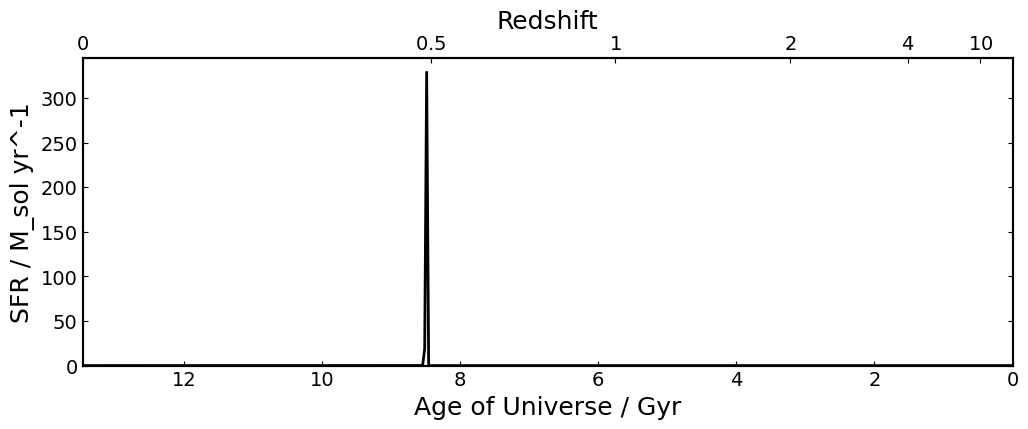

(<Figure size 1200x400 with 2 Axes>,
 <Axes: xlabel='Age of Universe / Gyr', ylabel='SFR / M_sol yr^-1'>)

In [18]:
SPEC_WAVS = np.arange(500., 150000., 5.)
plt.rcParams["text.usetex"] = False


dust = {}                         
dust["type"] = "Calzetti"         
dust["Av"] = 0.2                  
dust["eta"] = 2.                  

nebular = {}                      
nebular["logU"] = -3.             

exp = {}
exp["tau"] = 0.01
exp["age"] = 5
exp["massformed"] = 10.0
exp["metallicity"] = 0.5

model_components = {}                   
model_components["redshift"] = 0
model_components["t_bc"] = 0.01         
model_components["veldisp"] = 200. 
model_components["exponential"] = exp
model_components["dust"] = dust
model_components["nebular"] = nebular

model = pipes.model_galaxy(
    model_components,
    filt_list=filter_files
)

model.sfh.plot()